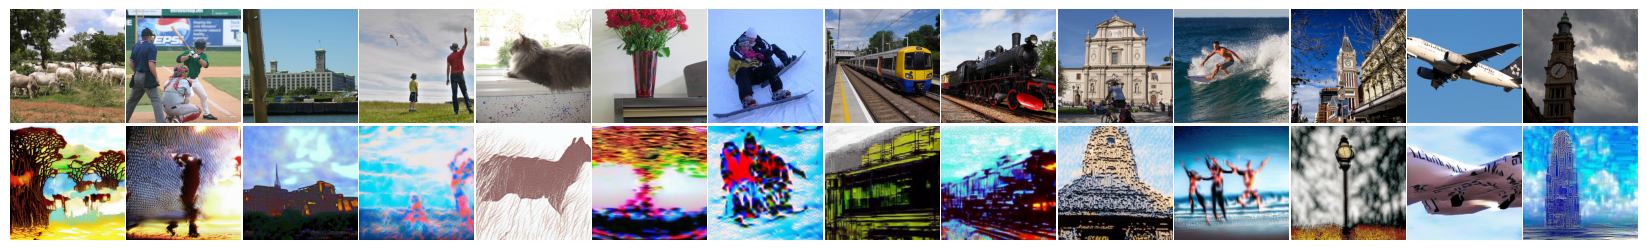

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# ==============================
# CONFIG
# ==============================
SAMPLES_DIR = "../decoded/image-cvpr/subj01/samples"  # change if needed
selection_string = "0, 6-2, 8, 14-2, 17, 18, 23-3, 35-3, 451, 450, 610-3, 709, 777-3, 792"

# ==============================
# PARSE INPUT STRING
# ==============================
def parse_selection(sel_str):
    items = sel_str.split(",")
    parsed = []
    
    for item in items:
        item = item.strip()
        if "-" in item:
            idx, recon = item.split("-")
            parsed.append((int(idx), int(recon)))
        else:
            parsed.append((int(item), 4))  # default: 4th reconstruction
    
    return parsed


# ==============================
# DISPLAY FUNCTION (Paper Style)
# ==============================
def display_paper_style(pairs):
    n = len(pairs)
    
    # small compact figure
    fig, axes = plt.subplots(2, n, figsize=(1.5*n, 3))
    
    for col, (img_idx, recon_num) in enumerate(pairs):
        img_name = f"{img_idx:05d}"
        
        org_path = os.path.join(SAMPLES_DIR, f"{img_name}_org.png")
        recon_index = recon_num - 1  # convert to 0-based
        recon_path = os.path.join(SAMPLES_DIR, f"{img_name}_{recon_index:03d}.png")
        
        org_img = Image.open(org_path)
        recon_img = Image.open(recon_path)
        
        # Row 1: Originals
        axes[0, col].imshow(org_img)
        axes[0, col].axis("off")
        
        # Row 2: Reconstructions
        axes[1, col].imshow(recon_img)
        axes[1, col].axis("off")
    
    plt.subplots_adjust(wspace=0.02, hspace=0.02)
    plt.show()


# ==============================
# RUN
# ==============================
parsed_pairs = parse_selection(selection_string)
display_paper_style(parsed_pairs)

**Examples:**
- `6` → Use image **00006** and display the **default reconstruction (4th sample)**.
- `6-2` → Use image **00006** and display the **2nd reconstruction sample**.